<h1>
Data Exploratory on NFL Quarterbacks' Statistics
</h1>

The NFL (National Football League) is one of the most well-known professional sports league in the world. A massive global TV audience of 62.5 million viewers tuned in to watch Super Bowl LVIII last season, an increase of 10%. [1] In the world of gridiron football, the focal point of the team lies in the quarterback (QB) position on the offensive team. Essentially a leader, the quarterback has huge responsibilities in taking charge of the offense, making key decisions and plays that ultimately determines the outcome of the game through their passing and running skill set, ability to read defenses, game management and being able to perform under pressure. This makes the quarterback a highly valuable and coveted position that teams are willing to offer multi-million contracts. What indicates a good quarterback though? Does a higher passing completion percentage reflect a higher quarterback rating? Or do experienced quarterbacks perform better than inexperienced ones? The rise of "dual-threat" quarterbacks can also come into discussion. The primary play of the quarterback is to pass the ball, however, "dual-threat" quarterbacks can run the ball as effective as they are in passing the ball through their athleticism, making them an unpredictable offensive weapon that keeps defenses on their toes. In this exploratory, I will be analysing NFL quarterbacks' statistics and evaluating their performance through the correlation of various factors. The dataset was acquired from Kaggle [2], a recognised online data science platform with a large community and it contains data of quarterbacks with 10 or more starts that played in the NFL from 2010 to 2021.

In [260]:
# os provides a way to interact with the operating system
import os

# Check if file exists
filename = 'qb_stats_2010_2021.csv'
if os.path.exists(filename):
    print(os.path.join(os.getcwd(), filename))
else:
    print("The file does not exist")

C:\Users\kille\qb_stats_2010_2021.csv


In [262]:
# pandas enables data manipulation 
import pandas as pd

# Read the CSV file
df = pd.read_csv('qb_stats_2010_2021.csv')

# Select the necessary columns
targeted_columns = [
    'Player', 'Rate', 'G', 'GS', 'From', 'To', 'Cmp%', 'Pass_Att', 'Pass_Yds', 'Pass_TD', 'Int',
    'GWD', '4QC', 'Rush_Att', 'Rush_Yds', 'Rush_TD', 'W', 'L', 'T', 'Team'
]

df = df[targeted_columns]
df.head(10)

,Player,Rate,G,GS,From,To,Cmp%,Pass_Att,Pass_Yds,Pass_TD,Int,GWD,4QC,Rush_Att,Rush_Yds,Rush_TD,W,L,T,Team
0,Matt Ryan,95.4,192,192,2010,2021,66.2,7118,53379,329,145,35.0,30.0,402,1316,10,100,92,0,ATL
1,Tom Brady,100.1,189,189,2010,2021,64.7,7099,53676,399,104,30.0,24.0,359,547,21,146,43,0,NWETAM
2,Philip Rivers,95.0,176,176,2010,2020,65.4,6220,48489,315,164,22.0,19.0,244,391,1,88,88,0,INDLACSDG
3,Aaron Rodgers,105.9,174,174,2010,2021,65.6,5982,46559,390,72,23.0,15.0,560,2802,25,122,51,1,GNB
4,Matthew Stafford,92.8,172,172,2010,2021,63.6,6448,47728,310,141,41.0,33.0,357,1133,12,84,87,1,DETLAR
5,Drew Brees,103.1,165,165,2010,2020,69.6,6387,49712,369,133,35.0,25.0,254,270,18,104,61,0,NOR
6,Ben Roethlisberger,94.2,162,161,2010,2021,64.9,6032,44786,291,130,34.0,26.0,287,675,8,105,55,1,PIT
7,Russell Wilson,101.8,158,158,2012,2021,65.0,4735,37059,292,87,32.0,24.0,846,4689,23,104,53,1,SEA
8,Andy Dalton,87.0,152,148,2011,2021,62.2,5018,35279,226,135,28.0,24.0,438,1411,22,77,69,2,CHICINDAL
9,Eli Manning,86.7,147,147,2010,2019,62.0,5326,38379,241,156,24.0,16.0,189,287,4,67,80,0,NYG


The dataset is being checked for duplicates and missing values as follows.

In [265]:
# Check for duplicate rows
duplicate = df[df.duplicated()]
duplicate

,Player,Rate,G,GS,From,To,Cmp%,Pass_Att,Pass_Yds,Pass_TD,Int,GWD,4QC,Rush_Att,Rush_Yds,Rush_TD,W,L,T,Team


In [267]:
# Check for missing values
null = df[df.isnull().any(axis=1)]
null

,Player,Rate,G,GS,From,To,Cmp%,Pass_Att,Pass_Yds,Pass_TD,Int,GWD,4QC,Rush_Att,Rush_Yds,Rush_TD,W,L,T,Team
85,Tarvaris Jackson,79.1,26,15,2010,2015,60.6,528,3620,18,17,NaN,NaN,59,164,2,7,8,0,MINSEA
87,DeShone Kizer,58.9,18,15,2017,2018,53.1,518,3081,11,24,NaN,NaN,82,458,5,0,15,0,CLEGNB
89,Jimmy Clausen,61.9,21,14,2010,2015,54.0,472,2520,7,14,NaN,NaN,37,102,0,1,13,0,BALCARCHI
91,Taysom Hill,72.5,33,13,2017,2021,57.4,141,1042,4,6,NaN,NaN,107,570,7,4,1,0,NOR
94,Cody Kessler,83.7,17,12,2016,2018,64.2,349,2215,8,5,NaN,NaN,31,140,0,2,10,0,CLEJAX
95,C.J. Beathard,81.4,21,12,2017,2021,58.7,499,3502,18,13,NaN,NaN,52,235,4,2,10,0,JAXSFO
96,Kellen Clemens,76.2,40,12,2010,2017,57.3,356,2373,11,10,NaN,NaN,41,108,2,4,8,0,LACNYJSDGSTL
97,Davis Mills,88.8,13,11,2021,2021,66.8,394,2664,16,10,NaN,NaN,18,44,0,2,9,0,HOU
102,Zach Mettenberger,75.4,14,10,2014,2015,60.3,345,2347,12,14,NaN,NaN,14,12,1,0,10,0,TEN
103,Justin Fields,73.2,12,10,2021,2021,58.9,270,1870,7,10,NaN,NaN,72,420,2,2,8,0,CHI


In [269]:
# Set null values
df.fillna(0, inplace=True)

Missing values were found to be present in the above rows of data, under the columns "GWD" and "4QC". After checking from the original source, Stathead [3], a reliable online statistical data platform created by a team of analytical data experts, all missing values were found to be 0 and inputted accordingly.

In [272]:
null = df[df.isnull().any(axis=1)]
null

,Player,Rate,G,GS,From,To,Cmp%,Pass_Att,Pass_Yds,Pass_TD,Int,GWD,4QC,Rush_Att,Rush_Yds,Rush_TD,W,L,T,Team


In [274]:
# Generate statistics of ratings
df["Rate"].describe()

count    105.00000
mean      84.32000
std        9.77809
min       58.90000
25%       77.90000
50%       84.50000
75%       90.70000
max      105.90000
Name: Rate, dtype: float64

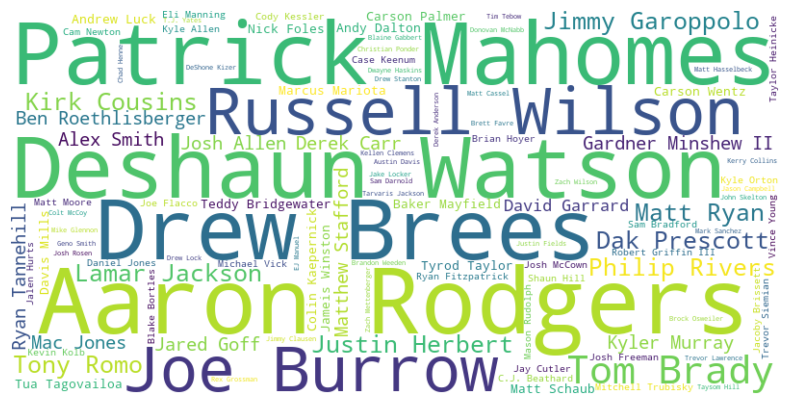

In [276]:
# WordCloud generates a word cloud for visualization purposes
from wordcloud import WordCloud
# matplotlib helps to create plots for visualization purposes
import matplotlib.pyplot as plt

# Create dictionary
word_freq = {row['Player']: row['Rate'] for index, row in df.iterrows()}

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

From the word cloud above, the font size of the quarterbacks' names represents the magnitude of their corresponding passer rating. The mean passer rating was found to be 84.3.

In [279]:
# Retrieve the lowest rated player
lowest_rated_player = df.loc[df['Rate'] == df['Rate'].min(), ['Player', 'Rate', 'From', 'To', 'Team']]
print(lowest_rated_player)

# Retrieve the highest rated player
highest_rated_player = df.loc[df['Rate'] == df['Rate'].max(), ['Player', 'Rate', 'From', 'To', 'Team']]
print(highest_rated_player)

           Player  Rate  From    To    Team
87  DeShone Kizer  58.9  2017  2018  CLEGNB
          Player   Rate  From    To Team
3  Aaron Rodgers  105.9  2010  2021  GNB


The lowest rated player (58.9) is DeShone Kizer who played for the Cleveland Browns and Green Bay Packers between 2017 and 2018 while the highest rated player is Aaron Rodgers (105.9) who played for the Green Bay Packers from 2010 to 2021.

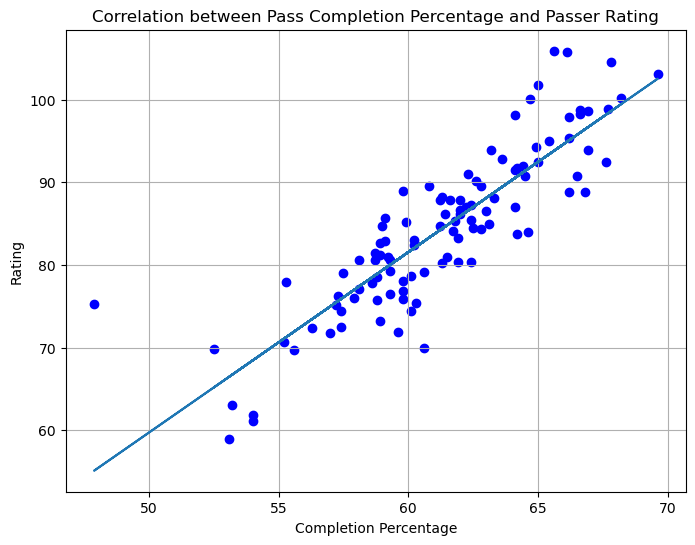

In [282]:
# numpy enables numerical computing
import numpy as np

# Linear regression calculation
a, b = np.polyfit(df['Cmp%'], df['Rate'], 1)

# Create the diagram
plt.figure(figsize=(8, 6))

# Create the scatter plot
plt.scatter(df['Cmp%'], df['Rate'], color='blue')

# Plot the best-fit line
plt.plot(df['Cmp%'], a*df['Cmp%']+b)  

# Set title and labels
plt.title("Correlation between Pass Completion Percentage and Passer Rating")
plt.xlabel("Completion Percentage")
plt.ylabel("Rating")
plt.grid(True)

# Show the plot
plt.show()

The above scatter plot shows the correlation between the pass completion percentage and the passer rating. There appears to be a positive correlation; as the pass completion percentage increases, the passer rating also increases. Most of the data points lie near the best-fit line which indicates a strong linear relationship between the 2 variables. It can thus be deduced that the pass completion percentage is a criteria in determining the passer rating. 

To evaluate how experienced a quarterback is, the number of years playing in the NFL is calculated. The quarterbacks are then grouped based on the calculations; 0-1 year for rookie, 2-8 years for seasoned and >=9 years for veteran.

In [286]:
# Create new column "Experience" and calculate values
df['Experience'] = df['To'] - df['From']
df = df.drop(['To', 'From'], axis=1)
df

,Player,Rate,G,GS,Cmp%,Pass_Att,Pass_Yds,Pass_TD,Int,GWD,4QC,Rush_Att,Rush_Yds,Rush_TD,W,L,T,Team,Experience
0,Matt Ryan,95.4,192,192,66.2,7118,53379,329,145,35.0,30.0,402,1316,10,100,92,0,ATL,11
1,Tom Brady,100.1,189,189,64.7,7099,53676,399,104,30.0,24.0,359,547,21,146,43,0,NWETAM,11
2,Philip Rivers,95.0,176,176,65.4,6220,48489,315,164,22.0,19.0,244,391,1,88,88,0,INDLACSDG,10
3,Aaron Rodgers,105.9,174,174,65.6,5982,46559,390,72,23.0,15.0,560,2802,25,122,51,1,GNB,11
4,Matthew Stafford,92.8,172,172,63.6,6448,47728,310,141,41.0,33.0,357,1133,12,84,87,1,DETLAR,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,Austin Davis,80.4,16,10,62.4,378,2548,13,12,2.0,1.0,24,68,0,3,7,0,CLESEASTL,3
101,Kerry Collins,77.9,13,10,55.3,376,2304,16,9,1.0,1.0,12,0,0,2,8,0,INDTEN,1
102,Zach Mettenberger,75.4,14,10,60.3,345,2347,12,14,0.0,0.0,14,12,1,0,10,0,TEN,1
103,Justin Fields,73.2,12,10,58.9,270,1870,7,10,0.0,0.0,72,420,2,2,8,0,CHI,0


In [288]:
# Group players based on experience
bins = [0, 1, 8, float('inf')] 
labels = ['Rookie', 'Seasoned', 'Veteran']  

# Create new column "Category"
df['Category'] = pd.cut(df['Experience'], bins=bins, labels=labels, right=True, include_lowest=True)
df

,Player,Rate,G,GS,Cmp%,Pass_Att,Pass_Yds,Pass_TD,Int,GWD,4QC,Rush_Att,Rush_Yds,Rush_TD,W,L,T,Team,Experience,Category
0,Matt Ryan,95.4,192,192,66.2,7118,53379,329,145,35.0,30.0,402,1316,10,100,92,0,ATL,11,Veteran
1,Tom Brady,100.1,189,189,64.7,7099,53676,399,104,30.0,24.0,359,547,21,146,43,0,NWETAM,11,Veteran
2,Philip Rivers,95.0,176,176,65.4,6220,48489,315,164,22.0,19.0,244,391,1,88,88,0,INDLACSDG,10,Veteran
3,Aaron Rodgers,105.9,174,174,65.6,5982,46559,390,72,23.0,15.0,560,2802,25,122,51,1,GNB,11,Veteran
4,Matthew Stafford,92.8,172,172,63.6,6448,47728,310,141,41.0,33.0,357,1133,12,84,87,1,DETLAR,11,Veteran
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,Austin Davis,80.4,16,10,62.4,378,2548,13,12,2.0,1.0,24,68,0,3,7,0,CLESEASTL,3,Seasoned
101,Kerry Collins,77.9,13,10,55.3,376,2304,16,9,1.0,1.0,12,0,0,2,8,0,INDTEN,1,Rookie
102,Zach Mettenberger,75.4,14,10,60.3,345,2347,12,14,0.0,0.0,14,12,1,0,10,0,TEN,1,Rookie
103,Justin Fields,73.2,12,10,58.9,270,1870,7,10,0.0,0.0,72,420,2,2,8,0,CHI,0,Rookie


In [290]:
# Calculate and print mean for each category
mean_rates = df.groupby('Category', observed=True)['Rate'].mean()
print(mean_rates)

Category
Rookie      80.588889
Seasoned    83.279365
Veteran     89.850000
Name: Rate, dtype: float64


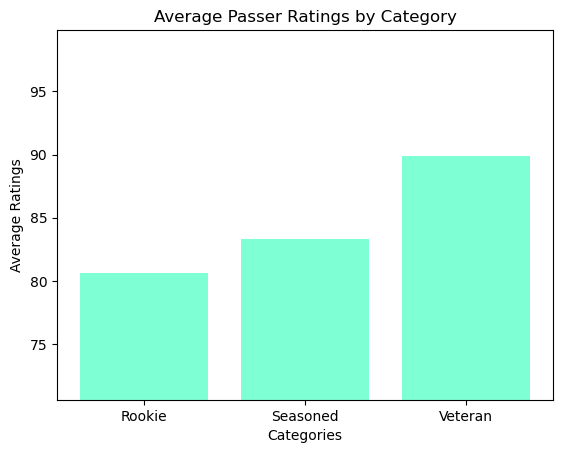

In [292]:
# Create the bar graph
plt.bar(mean_rates.index, mean_rates.values, color='aquamarine')

# Add titles and labels
plt.title('Average Passer Ratings by Category')
plt.xlabel('Categories')
plt.ylabel('Average Ratings')
plt.ylim(min(mean_rates.values) - 10, max(mean_rates.values) + 10)

# Show the plot
plt.show()

The above bar graph shows the mean passer rating across the different experience categories. There appears to be a positive trend where the mean passer ratings increase with experience. It can thus be deduced that experience also determines how well the quarterback performs.

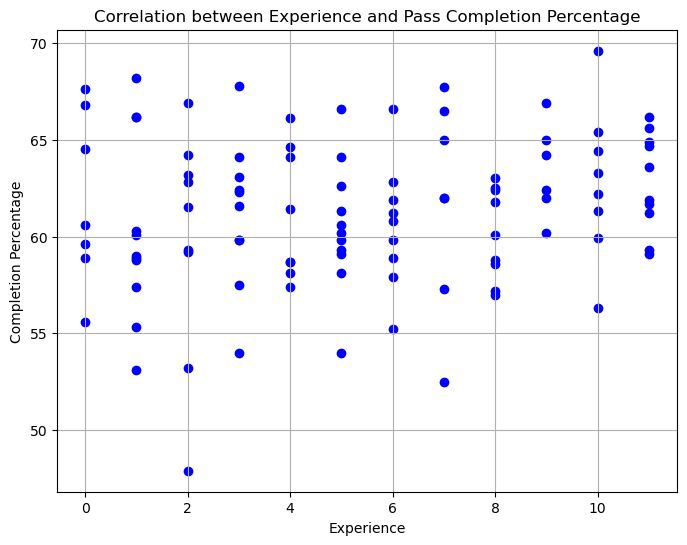

In [295]:
# Create the diagram
plt.figure(figsize=(8, 6))

# Create the scatter plot
plt.scatter(df['Experience'], df['Cmp%'], color='blue')

# Set title and labels
plt.title("Correlation between Experience and Pass Completion Percentage")
plt.xlabel("Experience")
plt.ylabel("Completion Percentage")
plt.grid(True)

# Show the plot
plt.show()

The above scatter plot shows the correlation between the experience and pass completion percentage. There appears to be no correlation between the 2 variables as the data points are scattered all over the graph. It can thus be deduced that the amount of experience does not affect how well the quarterback is able to pass the ball.

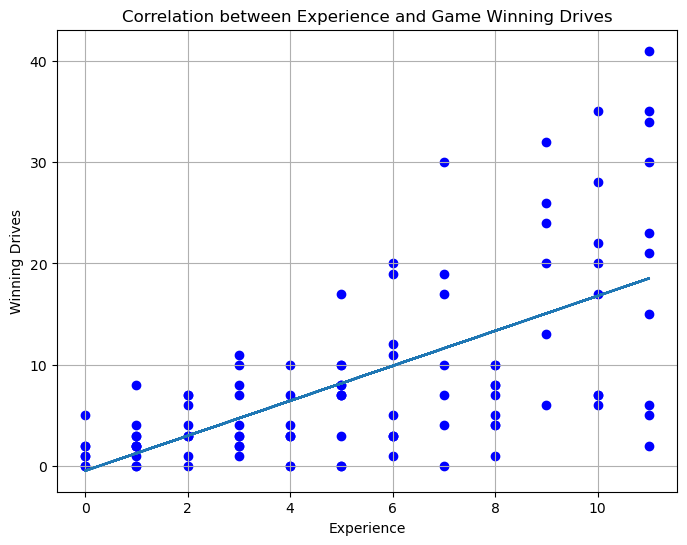

In [298]:
# Linear regression calculation
a, b = np.polyfit(df['Experience'], df['GWD'], 1)

# Create the diagram
plt.figure(figsize=(8, 6))

# Create the scatter plot
plt.scatter(df['Experience'], df['GWD'], color='blue')

# Plot the best-fit line
plt.plot(df['Experience'], a*df['Experience']+b)  

# Set title and labels
plt.title("Correlation between Experience and Game Winning Drives")
plt.xlabel("Experience")
plt.ylabel("Winning Drives")
plt.grid(True)

# Show the plot
plt.show()

The above scatter plot shows the correlation between the experience and game winning drives. There appears to be a positive correlation; as the years of experience increases, the number of game winning drives also increases. Most of the data points lie near the best-fit line which indicates a strong linear relationship between the 2 variables. However, the spread of data points gradually becomes wider and this means that the relationship becomes less significant for the more experienced players. 

To evaluate if a quarterback is considered to be "dual-threat", the percentage of rush attempts out of the total plays made is being calculated and high percentages of more than 15% are being accepted for this analysis.

In [302]:
# Create new column "Dual Threat Indicator" and calculate values
df['Dual_Threat_Indicator'] = (df['Rush_Att'] / (df['Rush_Att'] + df['Pass_Att'])) * 100
df

,Player,Rate,G,GS,Cmp%,Pass_Att,Pass_Yds,Pass_TD,Int,GWD,...,Rush_Att,Rush_Yds,Rush_TD,W,L,T,Team,Experience,Category,Dual_Threat_Indicator
0,Matt Ryan,95.4,192,192,66.2,7118,53379,329,145,35.0,...,402,1316,10,100,92,0,ATL,11,Veteran,5.345745
1,Tom Brady,100.1,189,189,64.7,7099,53676,399,104,30.0,...,359,547,21,146,43,0,NWETAM,11,Veteran,4.813623
2,Philip Rivers,95.0,176,176,65.4,6220,48489,315,164,22.0,...,244,391,1,88,88,0,INDLACSDG,10,Veteran,3.774752
3,Aaron Rodgers,105.9,174,174,65.6,5982,46559,390,72,23.0,...,560,2802,25,122,51,1,GNB,11,Veteran,8.560073
4,Matthew Stafford,92.8,172,172,63.6,6448,47728,310,141,41.0,...,357,1133,12,84,87,1,DETLAR,11,Veteran,5.246143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,Austin Davis,80.4,16,10,62.4,378,2548,13,12,2.0,...,24,68,0,3,7,0,CLESEASTL,3,Seasoned,5.970149
101,Kerry Collins,77.9,13,10,55.3,376,2304,16,9,1.0,...,12,0,0,2,8,0,INDTEN,1,Rookie,3.092784
102,Zach Mettenberger,75.4,14,10,60.3,345,2347,12,14,0.0,...,14,12,1,0,10,0,TEN,1,Rookie,3.899721
103,Justin Fields,73.2,12,10,58.9,270,1870,7,10,0.0,...,72,420,2,2,8,0,CHI,0,Rookie,21.052632


In [304]:
# Filter values of more than 15%
filtered_df = df[df['Dual_Threat_Indicator'] > 15]
filtered_df

,Player,Rate,G,GS,Cmp%,Pass_Att,Pass_Yds,Pass_TD,Int,GWD,...,Rush_Att,Rush_Yds,Rush_TD,W,L,T,Team,Experience,Category,Dual_Threat_Indicator
7,Russell Wilson,101.8,158,158,65.0,4735,37059,292,87,32.0,...,846,4689,23,104,53,1,SEA,9,Veteran,15.158574
10,Cam Newton,85.2,148,144,59.9,4474,32382,194,123,20.0,...,1118,5628,75,75,68,1,CARNWE,10,Veteran,19.992847
31,Josh Allen,91.0,61,60,62.3,1999,14114,103,46,11.0,...,422,2325,31,39,21,0,BUF,3,Seasoned,17.430814
33,Colin Kaepernick,88.9,69,58,59.8,1692,12271,72,30,7.0,...,375,2300,13,28,30,0,SFO,5,Seasoned,18.142235
37,Tyrod Taylor,88.2,78,53,61.3,1542,10736,59,25,6.0,...,361,2001,19,26,25,1,BALBUFCLEHOULAC,10,Veteran,18.970047
42,Lamar Jackson,98.1,58,49,64.1,1329,9967,84,31,8.0,...,615,3673,21,37,12,0,BAL,3,Seasoned,31.635802
46,Michael Vick,85.7,57,47,59.1,1474,10873,61,36,7.0,...,320,2155,13,23,23,0,NYJPHIPIT,5,Seasoned,17.837235
47,Kyler Murray,93.9,46,46,66.9,1581,11480,70,34,7.0,...,314,1786,20,22,23,1,ARI,2,Seasoned,16.569921
50,Robert Griffin III,86.5,56,42,63.0,1268,9271,43,30,5.0,...,307,1809,10,16,26,0,BALCLEWAS,8,Seasoned,19.492063
71,Jalen Hurts,84.7,30,19,59.0,580,4205,22,13,2.0,...,202,1138,13,9,10,0,PHI,1,Rookie,25.831202


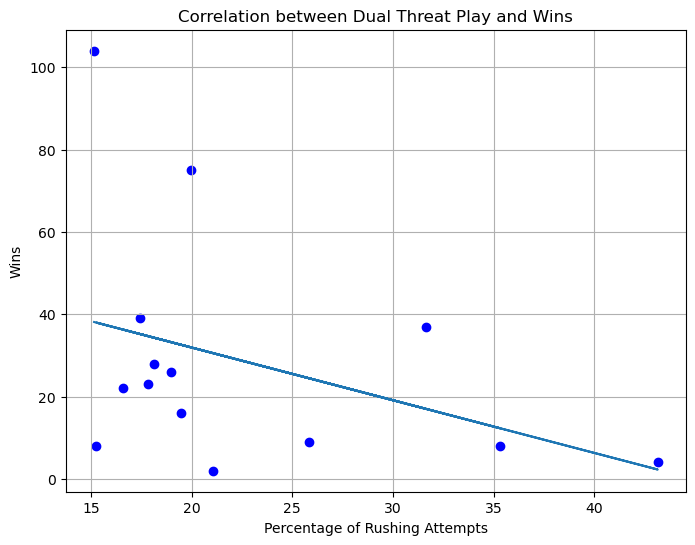

In [306]:
# Linear regression calculation
a, b = np.polyfit(filtered_df['Dual_Threat_Indicator'], filtered_df['W'], 1)

# Create the diagram
plt.figure(figsize=(8, 6))

# Create the scatter plot
plt.scatter(filtered_df['Dual_Threat_Indicator'], filtered_df['W'], color='blue')

# Plot the best-fit line
plt.plot(filtered_df['Dual_Threat_Indicator'], a*filtered_df['Dual_Threat_Indicator']+b)  

# Add title and labels
plt.title("Correlation between Dual Threat Play and Wins")
plt.xlabel("Percentage of Rushing Attempts")
plt.ylabel("Wins")
plt.grid(True)

# Show the plot
plt.show()

The above scatter plot shows the correlation between the percentage of rushing attempts and wins. There appears to be a negative correlation; as the percentage of rushing attempts increases, the number of wins decreases. Most of the data points lie near the best-fit line which indicates a strong linear relationship between the 2 variables. It can thus be deduced that the "dual-threat" quarterbacks are less likely to achieve more wins if they focus more on the rushing game. 

There are, however, other external factors that contribute to the performance of the quarterback. One such example is the major rule change in 2018 as follows.

In [310]:
# requests helps to make HTTP requests
import requests

# HTTP GET request to retrieve the webpage from the URL
link = "https://www.sbnation.com/nfl/2018/9/27/17911444/nfl-roughing-the-passer-penalty-explanation-clay-matthews"
page = requests.get(link)
page

<Response [200]>

In [311]:
# BeautifulSoup enables web scraping
from bs4 import BeautifulSoup as bs

# Parse the HTML content of the webpage
soup = bs(page.content, 'html.parser')

# Retrieve elements based on id
para_1 = soup.find('p', id='Ek8rsX')
para_2 = soup.find('p', id='uYWFDJ')
header = soup.find('h3', id='N3MINv')
para_3 = soup.find('p', id='NelXvc')
blockquote = soup.find('p', id='P9QYUI')
para_4 = soup.find('p', id='NRtTN6')

# Extract and print all text from the elements
print(para_1.get_text(), para_2.get_text(), header.get_text(), para_3.get_text(), blockquote.get_text(), para_4.get_text())

It’s not easy to record a sack in the NFL, and the pass rushers who have managed to do so have had difficulty avoiding personal fouls along the way. Earlier in the offseason, the league added an article to its roughing the passer rules that bans defenders landing on a quarterback. That’s a difficult violation to avoid and it’s created a storm of criticism from defenders and quarterbacks alike. What is the new rule? Here is the new aspect of the rule under the microscope, via Rule 12, Section 2, Article 9 of the NFL rulebook: A rushing defender is prohibited from committing such intimidating and punishing acts as “stuffing” a passer into the ground or unnecessarily wrestling or driving him down after the passer has thrown the ball, even if the rusher makes his initial contact with the passer within the one-step limitation provided for in (a) above. When tackling a passer who is in a defenseless posture (e.g., during or just after throwing a pass), a defensive player must not unnecessari

In [314]:
# nltk processes text-based data
import nltk
# word_tokenize performs tokenization
from nltk import word_tokenize
# punkt is a word tokenization model
nltk.download('punkt')

# Extract the text from each element
text_1 = para_1.get_text()
text_2 = para_2.get_text()
header_text = header.get_text()
text_3 = para_3.get_text()
blockquote_text = blockquote.get_text()
text_4 = para_4.get_text()

# Combine the extracted text 
combined_text = text_1 + ' ' + text_2 + ' ' + header_text + ' ' + text_3 + ' ' + blockquote_text + ' ' + text_4

# Tokenize the combined text
words = word_tokenize(combined_text)

# Print the list of words
print(words)

['It', '’', 's', 'not', 'easy', 'to', 'record', 'a', 'sack', 'in', 'the', 'NFL', ',', 'and', 'the', 'pass', 'rushers', 'who', 'have', 'managed', 'to', 'do', 'so', 'have', 'had', 'difficulty', 'avoiding', 'personal', 'fouls', 'along', 'the', 'way', '.', 'Earlier', 'in', 'the', 'offseason', ',', 'the', 'league', 'added', 'an', 'article', 'to', 'its', 'roughing', 'the', 'passer', 'rules', 'that', 'bans', 'defenders', 'landing', 'on', 'a', 'quarterback', '.', 'That', '’', 's', 'a', 'difficult', 'violation', 'to', 'avoid', 'and', 'it', '’', 's', 'created', 'a', 'storm', 'of', 'criticism', 'from', 'defenders', 'and', 'quarterbacks', 'alike', '.', 'What', 'is', 'the', 'new', 'rule', '?', 'Here', 'is', 'the', 'new', 'aspect', 'of', 'the', 'rule', 'under', 'the', 'microscope', ',', 'via', 'Rule', '12', ',', 'Section', '2', ',', 'Article', '9', 'of', 'the', 'NFL', 'rulebook', ':', 'A', 'rushing', 'defender', 'is', 'prohibited', 'from', 'committing', 'such', 'intimidating', 'and', 'punishing', 'a

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kille\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [316]:
# FreqDist calculates the frequency of words
from nltk.probability import FreqDist

#  Count words
data_analysis = FreqDist(words)

#  Show the word counts
word_count = {word: freq for word, freq in data_analysis.items()}
print(word_count)

{'It': 1, '’': 5, 's': 5, 'not': 3, 'easy': 1, 'to': 7, 'record': 1, 'a': 12, 'sack': 1, 'in': 4, 'the': 26, 'NFL': 3, ',': 12, 'and': 5, 'pass': 2, 'rushers': 1, 'who': 2, 'have': 2, 'managed': 1, 'do': 1, 'so': 1, 'had': 1, 'difficulty': 1, 'avoiding': 1, 'personal': 1, 'fouls': 1, 'along': 1, 'way': 1, '.': 8, 'Earlier': 1, 'offseason': 1, 'league': 1, 'added': 1, 'an': 1, 'article': 1, 'its': 1, 'roughing': 1, 'passer': 7, 'rules': 1, 'that': 3, 'bans': 1, 'defenders': 2, 'landing': 1, 'on': 4, 'quarterback': 1, 'That': 1, 'difficult': 1, 'violation': 1, 'avoid': 1, 'it': 2, 'created': 1, 'storm': 1, 'of': 9, 'criticism': 1, 'from': 2, 'quarterbacks': 1, 'alike': 1, 'What': 1, 'is': 4, 'new': 2, 'rule': 4, '?': 1, 'Here': 1, 'aspect': 1, 'under': 1, 'microscope': 1, 'via': 1, 'Rule': 1, '12': 1, 'Section': 1, '2': 1, 'Article': 1, '9': 1, 'rulebook': 1, ':': 1, 'A': 1, 'rushing': 1, 'defender': 2, 'prohibited': 1, 'committing': 1, 'such': 1, 'intimidating': 1, 'punishing': 1, 'acts

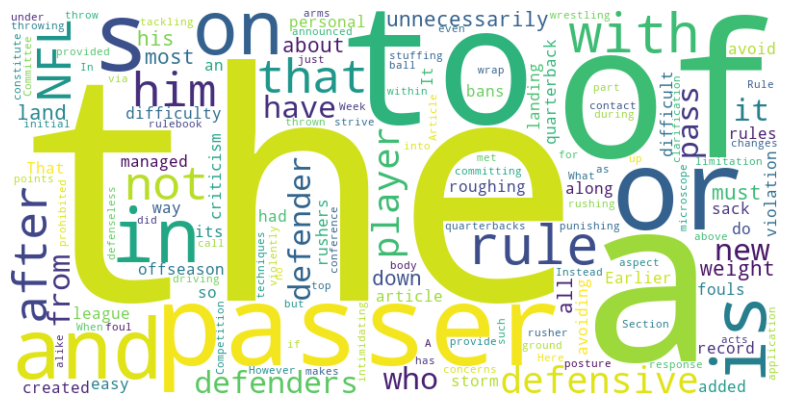

In [318]:
# Create dictionary
filtered_counter = {word: freq for word, freq in data_analysis.items() if word.isalpha()}

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(filtered_counter)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  
plt.show()

The above rule change of "Roughing the Passer" is a game-changer as it greatly benefits the quarterback in many ways. Injuries are a commonplace in contact sports like gridiron football and the importance of keeping the quarterback healthy can define how successful a season will be. By imposing a stricter set of rules that prohibits a defensive player from committing too aggressive a tackle on the quarterback after making a passing play, this decreases the likelihood of injury on the quarterback. With increased protection, the quarterback will be able to make better decisions with less pressure and more time in the pocket to pass or run the ball which boosts their performance.

From the exploratory, it can be concluded that there are a variety of factors contributing to the performance of the quarterback. The analysis effectively addressed the potential questions that were stated earlier in the introduction in a systematic manner and had a smooth overall workflow.
It can prove beneficial to NFL teams as the valuable insights that are acquired through the identification of correlations and patterns between the different statistical data can be crucial in the fields of player skill set evaluation and strategic planning. Key performance indicators can ultimately play a significant role in enhancing the play calling, game management and roster development of quarterbacks, optimizing team performance as a whole.

<h3>Appendix</h3>

[1] https://www.nfl.com/news/global-audience-of-62-5-million-watched-super-bowl-lviii-an-increase-of-10-percent-over-2023

[2] https://www.kaggle.com/datasets/mgavinf/qb-stats-2010-2021

[3] https://stathead.com/football/